# Task 1: Student Score Prediction

## Selecting Data for Modeling
📌 Your dataset had  too many variables to wrap your head around, or even to print out nicely.  How can you pare down this overwhelming amount of data to something you can understand?

📌 We'll start by picking a few variables using our intuition. ther is also statistical techniques to automatically prioritize variables.

📌 To choose variables/columns, we'll need to see a list of all columns in the dataset. That is done with the **columns** property of the DataFrame (the bottom line of code below).


In [ ]:
import gdown
import pandas as pd

url = "https://drive.google.com/uc?id=1l4Ufg1ruFHEonk7Ok0--ogwXg4yZ1M4K"
Student_performance_file_path = "Student_performance_data.csv"
gdown.download(url, Student_performance_file_path, quiet=False)

df = pd.read_csv(Student_performance_file_path)
df.columns

Downloading...
From: https://drive.google.com/uc?id=1l4Ufg1ruFHEonk7Ok0--ogwXg4yZ1M4K
To: c:\Users\user\Desktop\Elevvo ML Internship Program\materials\4- Your First ML Model\Student_performance_data.csv
100%|██████████| 167k/167k [00:00<00:00, 245kB/s]


Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

In [6]:
print(df.shape)
print(df.head())

(2392, 15)
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1      

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None


# Choosing "Features"

By convention, this data is called **X**.

In [9]:
# Select study hours and GPA
X = df[["StudyTimeWeekly"]]   # independent variable


📌 Let's quickly review the data we'll be using to predict house prices using the `describe` method and the `head` method, which shows the top few rows.

In [10]:
X.describe()

,StudyTimeWeekly
count,2392.000000
mean,9.771992
std,5.652774
min,0.001057
25%,5.043079
50%,9.705363
75%,14.408410
max,19.978094


In [11]:
X.head()

,StudyTimeWeekly
0,19.833723
1,15.408756
2,4.210570
3,10.028829
4,4.672495


In [ ]:
# target variable
y = df["GPA"]    

# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Building Your Model

📌 You will use the **scikit-learn** library to create your models.  When coding, this library is written as **sklearn**, as you will see in the sample code. Scikit-learn is easily the most popular library for modeling the types of data typically stored in DataFrames.

📌 The steps to building and using a model are:
* **Define:** What type of model will it be?  A Linear Regression?  Some other type of model? 
* **Fit:** Capture patterns from provided data. This is the heart of modeling.
* **Predict:** Just what it sounds like
* **Evaluate**: Determine how accurate the model's predictions are.

Here is an example of defining a Linear Regression model with scikit-learn and fitting it with the features and target variable.

In [14]:
from sklearn.linear_model import LinearRegression

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

📌 We now have a fitted model that we can use to make predictions.

In [16]:
# Predictions
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_[0])
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Intercept (b0): 1.5964706415347973
Coefficient (b1): 0.03125081011912532
MAE: 0.763
MSE: 0.821
RMSE: 0.906
R²: 0.007


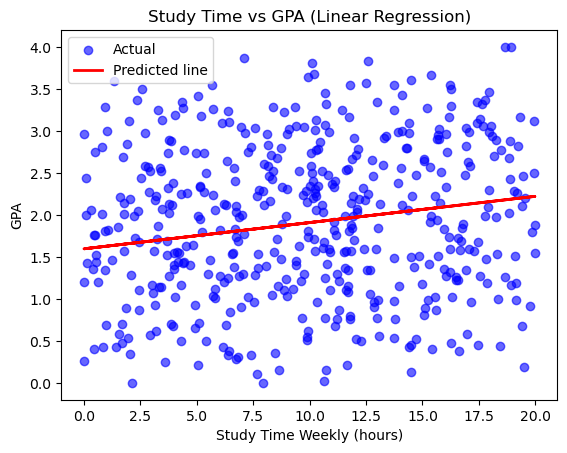

In [20]:
import matplotlib.pyplot as plt

# Visualization: scatter + regression line
plt.scatter(X_test, y_test, color="blue", alpha=0.6, label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted line")
plt.xlabel("Study Time Weekly (hours)")
plt.ylabel("GPA")
plt.title("Study Time vs GPA (Linear Regression)")
plt.legend()
plt.show()